In [1]:
import sys
sys.path.append("../../")

In [2]:
import torch
import numpy as np
import random
import pandas as pd
import os
from scipy import stats
from datetime import datetime

from NEW_PINN_LLM_SUR.LLM_epiparam_generator.agents.PINN_const import EINN_PINN


# ============================================
# Seed
# ============================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ============================================
# Данные
# ============================================

covid_cases = pd.read_csv('../real_datasets/covid-19_Kouprianov.csv')

S = covid_cases['S'].values
I = covid_cases['I'].values
D = covid_cases['D'].values
R = covid_cases['R'].values

timesteps = np.arange(len(S)).astype(float)

train_size = 185
population = S[0] + I[0] + R[0] + D[0]


# ============================================
# Новый набор параметров
# ============================================

new_params = {
    "beta": 0.0724,
    "gamma": 0.0325,
    "mu": 0.00195
}

n_runs = 20


# ============================================
# Пути
# ============================================

output_dir = "./experiment_results"
os.makedirs(output_dir, exist_ok=True)

new_results_path = os.path.join(output_dir, "new_v2_results.csv")
baseline_path = os.path.join(output_dir, "peak_results.csv")


# ============================================
# Запуск эксперимента
# ============================================

results = []

for run in range(n_runs):

    seed = 100 + run
    print(f"\nRun {run+1} | seed={seed}")

    set_seed(seed)

    model = EINN_PINN(
        t=timesteps,
        S_data=S,
        I_data=I,
        R_data=R,
        D_data=D,
        population=population,
        train_size=train_size,
        init_params=new_params,
        device='cuda'
    )

    model.train_model(
        n_epoch=10_000,
        lambda_data=1.0,
        lambda_ode=1.0,
        lambda_ic=0.1,
        lambda_bc=0.1
    )

    S_pred, I_pred, R_pred, D_pred = model.predict(timesteps)
    I_pred = I_pred.numpy()

    peak_pos = np.argmax(I_pred)
    peak_height = np.max(I_pred)

    params = model.params.get_params_dict()

    results.append({
        "type": "new_v2",
        "seed": seed,
        "peak_position": peak_pos,
        "peak_height": peak_height,
        "beta": params["beta"],
        "gamma": params["gamma"],
        "mu": params["mu"]
    })

    print(f"Peak pos = {peak_pos}")
    print(f"Peak height = {peak_height:.2f}")
    print(f"beta={params['beta']:.5f}, gamma={params['gamma']:.5f}, mu={params['mu']:.5f}")


# ============================================
# Сохранение
# ============================================


timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
new_results_path = os.path.join(
    output_dir, f"new_v2_results_{timestamp}.csv"
)

new_df = pd.DataFrame(results)
new_df.to_csv(new_results_path, index=False)


print(f"\nSaved to {new_results_path}")


# ============================================
# Стат значимость vs baseline
# ============================================

baseline_df = pd.read_csv(baseline_path)


# Берём только baseline
baseline = baseline_df[baseline_df["type"] == "baseline"]
new_v2 = new_df


def cohens_d(x, y):
    nx = len(x)
    ny = len(y)

    pooled_std = np.sqrt(
        ((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) /
        (nx + ny - 2)
    )

    return (np.mean(x) - np.mean(y)) / pooled_std


print("\n" + "="*60)
print("STATISTICAL SIGNIFICANCE VS BASELINE")
print("="*60)


# Peak height

t_stat, t_p = stats.ttest_ind(
    baseline["peak_height"],
    new_v2["peak_height"]
)

u_stat, u_p = stats.mannwhitneyu(
    baseline["peak_height"],
    new_v2["peak_height"]
)

d = cohens_d(
    baseline["peak_height"],
    new_v2["peak_height"]
)

print("\nPeak Height")
print(f"T-test p = {t_p:.6f}")
print(f"Mann-Whitney p = {u_p:.6f}")
print(f"Cohen d = {d:.4f}")


# Peak position

t_stat, t_p = stats.ttest_ind(
    baseline["peak_position"],
    new_v2["peak_position"]
)

u_stat, u_p = stats.mannwhitneyu(
    baseline["peak_position"],
    new_v2["peak_position"]
)

d = cohens_d(
    baseline["peak_position"],
    new_v2["peak_position"]
)

print("\nPeak Position")
print(f"T-test p = {t_p:.6f}")
print(f"Mann-Whitney p = {u_p:.6f}")
print(f"Cohen d = {d:.4f}")


Run 1 | seed=100


c:\Users\dinara\Desktop\НИР\Code\PINN_LLM\venv\Lib\site-packages\torch\optim\lr_scheduler.py:1340: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  current = float(metrics)


Epoch     0 | Loss: 13117523968.000000 | Data: 12738262016.000000 | ODE: 3013355.250000
Params: β=0.0724, γ=0.0325, μ=0.0020
---
Epoch  1000 | Loss: 1584219648.000000 | Data: 692345088.000000 | ODE: 23506694.000000
Params: β=0.0724, γ=0.0325, μ=0.0020
---
Epoch  2000 | Loss: 19182988.000000 | Data: 14344778.000000 | ODE: 4721998.500000
Params: β=0.0724, γ=0.0325, μ=0.0020
---
Epoch  3000 | Loss: 10074605.000000 | Data: 5773930.000000 | ODE: 4294063.500000
Params: β=0.0724, γ=0.0325, μ=0.0020
---
Epoch  4000 | Loss: 9421995.000000 | Data: 5468905.500000 | ODE: 3946676.750000
Params: β=0.0724, γ=0.0325, μ=0.0020
---
Epoch  5000 | Loss: 9466910.000000 | Data: 5863645.000000 | ODE: 3596796.500000
Params: β=0.0724, γ=0.0325, μ=0.0020
---
Epoch  6000 | Loss: 7621176.000000 | Data: 4314834.000000 | ODE: 3300003.000000
Params: β=0.0724, γ=0.0325, μ=0.0020
---
Epoch  7000 | Loss: 7189939.500000 | Data: 4110177.250000 | ODE: 3073433.500000
Params: β=0.0724, γ=0.0325, μ=0.0020
---
Epoch  8000 | L

KeyboardInterrupt: 

In [18]:
import pandas as pd
from scipy import stats

# baseline уже сохранён
baseline_df = pd.read_csv("experiment_results/peak_results_main_real_spb.csv")

# new_v2 только что посчитан
new_df = pd.read_csv("experiment_results/new_v2_results_20260421_141232.csv")


baseline = baseline_df[baseline_df["type"] == "baseline"]
new_v2 = new_df


def cohens_d(x, y):
    nx, ny = len(x), len(y)

    pooled_std = ((nx - 1) * x.var(ddof=1) +
                  (ny - 1) * y.var(ddof=1)) / (nx + ny - 2)
    pooled_std = pooled_std ** 0.5

    return (x.mean() - y.mean()) / pooled_std


# ============================================
# PEAK HEIGHT
# ============================================

t_stat, p_t = stats.ttest_ind(
    baseline["peak_height"],
    new_v2["peak_height"]
)

u_stat, p_u = stats.mannwhitneyu(
    baseline["peak_height"],
    new_v2["peak_height"]
)

d = cohens_d(
    baseline["peak_height"],
    new_v2["peak_height"]
)

print("\nPEAK HEIGHT")
print("t-test p-value:", p_t)
print("Mann-Whitney p-value:", p_u)
print("Cohen d:", d)


# ============================================
# PEAK POSITION
# ============================================

t_stat, p_t = stats.ttest_ind(
    baseline["peak_position"],
    new_v2["peak_position"]
)

u_stat, p_u = stats.mannwhitneyu(
    baseline["peak_position"],
    new_v2["peak_position"]
)

d = cohens_d(
    baseline["peak_position"],
    new_v2["peak_position"]
)

print("\nPEAK POSITION")
print("t-test p-value:", p_t)
print("Mann-Whitney p-value:", p_u)
print("Cohen d:", d)


PEAK HEIGHT
t-test p-value: 0.0408607962956662
Mann-Whitney p-value: 0.014363847601136407
Cohen d: -0.6694650067348451

PEAK POSITION
t-test p-value: 0.05669963120649083
Mann-Whitney p-value: 0.030188942437625255
Cohen d: -0.6215360439603613


СТАТИСТИКА ПО ГРУППАМ
МЕДИАНА peak_position:
type
baseline    198.0
new_v2      193.0
Name: peak_position, dtype: float64

СРЕДНЕЕ peak_height:
type
baseline    97842.29
new_v2      95614.50
Name: peak_height, dtype: float64


new_v2 - МЕДИАНА peak_position: 193.0
new_v2 - СРЕДНЕЕ peak_height: 95614.5


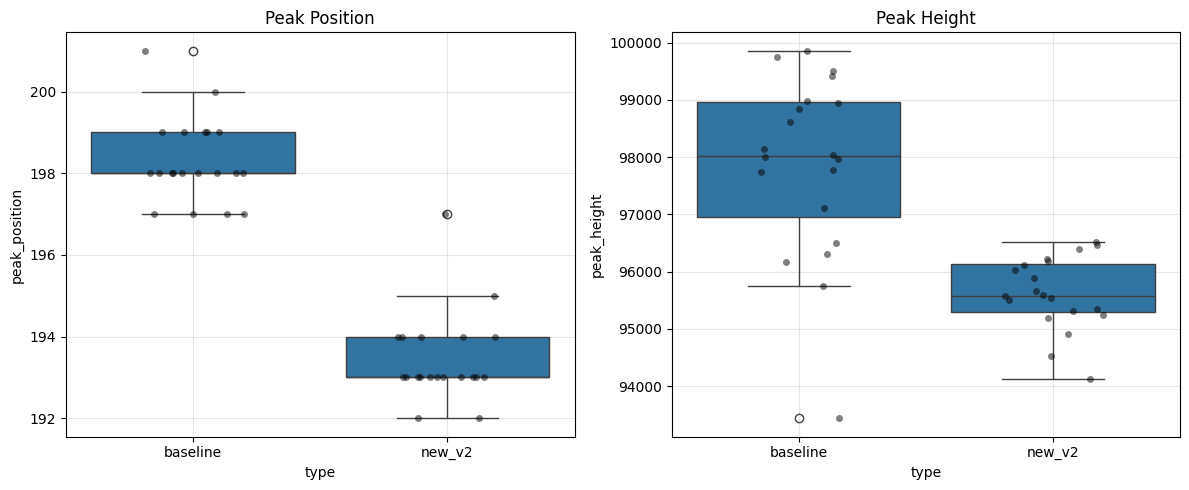

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# загрузка данных
baseline_df = pd.read_csv("experiment_results/peak_results_main_real_spb.csv")
new_df = pd.read_csv("experiment_results/new_v2_results_20260421_125712.csv")

baseline = baseline_df[baseline_df["type"] == "baseline"].copy()
new_v2 = new_df.copy()

# объединяем
plot_df = pd.concat([baseline, new_v2], ignore_index=True)


# ============================================
# ВЫВОД СРЕДНИХ ЗНАЧЕНИЙ И МЕДИАН
# ============================================

print("=" * 50)
print("СТАТИСТИКА ПО ГРУППАМ")
print("=" * 50)

# Статистика для peak_position (медиана) и peak_height (среднее)
stats_position = plot_df.groupby('type')['peak_position'].median().round()
stats_height = plot_df.groupby('type')['peak_height'].mean().round(2)

print("МЕДИАНА peak_position:")
print(stats_position)
print("\nСРЕДНЕЕ peak_height:")
print(stats_height)
print("\n")

# Для new_v2 отдельно
new_v2_median_position = new_v2['peak_position'].median().round()
new_v2_mean_height = new_v2['peak_height'].mean().round(2)

print(f"new_v2 - МЕДИАНА peak_position: {new_v2_median_position}")
print(f"new_v2 - СРЕДНЕЕ peak_height: {new_v2_mean_height}")
print("=" * 50)

# ============================================
# FIGURE
# ============================================

plt.figure(figsize=(12, 5))

# --------------------------------------------
# Peak Position
# --------------------------------------------
plt.subplot(1, 2, 1)
sns.boxplot(data=plot_df, x="type", y="peak_position")
sns.stripplot(data=plot_df, x="type", y="peak_position",
              color="black", alpha=0.5, jitter=0.2)

plt.title("Peak Position")
plt.grid(True, alpha=0.3)


# --------------------------------------------
# Peak Height
# --------------------------------------------
plt.subplot(1, 2, 2)
sns.boxplot(data=plot_df, x="type", y="peak_height")
sns.stripplot(data=plot_df, x="type", y="peak_height",
              color="black", alpha=0.5, jitter=0.2)

plt.title("Peak Height")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
new_v2['peak_position'].median()

np.float64(199.5)